In [1]:

versioninfo()


Julia Version 1.12.3
Commit 966d0af0fdf (2025-12-15 11:20 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 16 × AMD Ryzen 7 7800X3D 8-Core Processor
  WORD_SIZE: 64
  LLVM: libLLVM-18.1.7 (ORCJIT, znver4)
  GC: Built with stock GC
Threads: 16 default, 1 interactive, 16 GC (on 16 virtual cores)
Environment:
  JULIA_NUM_THREADS = 16



# ERP Image Preprocessing Challenge

This notebook challenges the current ERP image reference pipeline `sort -> zscore -> gaussian -> resize`.

The goal is to test whether a morphological filter should replace or complement Gaussian smoothing when the CNN receives only a single input channel.

Key constraints for this notebook:

- only real fixation ERP data are used
- the modulo-4 sample construction is reused
- the grouped 5-fold split is reused with balanced distribution
- two single-channel `ResNet18` variants are compared
  - random initialization
  - ImageNet-pretrained initialization adapted to one input channel

The notebook focuses on the morphological filters from `notebooks/model_test/erp_image_processing.ipynb`, because the earlier follow-up experiment used that filter family as an additional channel.


In [2]:

import Pkg

# Keep startup stable and reuse the notebook environment from model_test.
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = "0"
ENV["JULIA_NUM_PRECOMPILE_TASKS"] = "1"

const NOTEBOOK_DIR = pwd()
Pkg.activate(joinpath(NOTEBOOK_DIR, "..", "model_test"))

using CairoMakie
using CUDA
using DataFrames
using Flux
using PrettyTables
using Random
using Statistics

include(joinpath(NOTEBOOK_DIR, "..", "utils", "erp_cnn_experiment_utils.jl"))
using .ERPCNNExperimentUtils

@assert CUDA.functional(true) "CUDA is not functional. This notebook expects GPU training."
CUDA.allowscalar(false)
CUDA.device!(0)

gpu_name = CUDA.name(CUDA.device())
println("CUDA device: ", gpu_name)

device(x) = gpu(x)
before_fold!() = CUDA.reclaim()
after_fold!() = begin
    CUDA.reclaim()
    GC.gc(true)
end

const SAMPLING_RATE = 512
const PRE_STIM_S = 0.5
const TIME_ZERO_IDX = Int(round(PRE_STIM_S * SAMPLING_RATE)) + 1
const TARGET_SIZE = (64, 64)
const LOWPASS_SIGMA = 75.0f0
const LOWPASS_KERNEL_SIZE = (21, 21)
const FILTER_BORDER = "reflect"

const POSITIVE_SPLIT_K = 4
const NO_CLASS_SPLIT_K = 4
const K_FOLDS = 5

seed_base_ns = time_ns()
seed_base = Int(mod(seed_base_ns, typemax(Int) - 2))
NO_CLASS_PICK_SEED = seed_base
FOLD_SPLIT_SEED = seed_base + 1
TRAINING_SEED_BASE = seed_base + 2

println("Run seed base (time_ns): ", seed_base_ns)
println("No-class split seed    : ", NO_CLASS_PICK_SEED)
println("Fold split seed        : ", FOLD_SPLIT_SEED)
println("Training seed base     : ", TRAINING_SEED_BASE)

table_kwargs = (
    fit_table_in_display_horizontally = false,
    fit_table_in_display_vertically = false,
    display_size = (10_000, 10_000),
    show_omitted_cell_summary = false,
)


  Activating project at `~/Dokumente/BA2/notebooks/model_test`


CUDA device: NVIDIA GeForce RTX 4070
Run seed base (time_ns): 14772943300573
No-class split seed    : 14772943300573
Fold split seed        : 14772943300574
Training seed base     : 14772943300575


(fit_table_in_display_horizontally = false, fit_table_in_display_vertically = false, display_size = (10000, 10000), show_omitted_cell_summary = false)


## Real Data Only

This section loads exactly the real fixation ERP sources that were already used in the semi-supervised notebook. No synthetic data are added.


In [3]:

# Load the real fixation ERP inputs and the merged label table.
data_ctx = prepare_real_fixations_inputs(NOTEBOOK_DIR)

erps = data_ctx.erps
events = data_ctx.events
labels_df = data_ctx.labels_df

println("ERP tensor size: ", size(erps), " (channel, time, trial)")
println("Events rows: ", nrow(events))
println("Merged labels used for training: ", nrow(labels_df))

source_df = DataFrame(
    source = [
        "results_csv_1",
        "results_csv_2",
        "erp_hdf5",
        "events_csv",
    ],
    path = [
        data_ctx.results_csv_paths[1],
        data_ctx.results_csv_paths[2],
        data_ctx.h5_path,
        data_ctx.events_csv_path,
    ],
)

label_dist_df = combine(groupby(labels_df, :binary_label), nrow => :count)
sort!(label_dist_df, :binary_label)

label_sort_df = combine(groupby(labels_df, [:binary_label, :sort_variable]), nrow => :count)
sort!(label_sort_df, [:binary_label, :sort_variable])

println("\nInput sources:")
pretty_table(source_df; table_kwargs...)

println("\nLabel distribution:")
pretty_table(label_dist_df; table_kwargs...)

println("\nLabel distribution by sort variable:")
pretty_table(label_sort_df; table_kwargs...)


ERP tensor size: (128, 769, 2508) (channel, time, trial)
Events rows: 2508
Merged labels used for training: 500

Input sources:
┌───────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│        source │                                                                                                   path │
│        String │                                                                                                 String │
├───────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ results_csv_1 │  /home/benjamin/Dokumente/BA2/notebooks/model_test/results/project-14-at-2026-02-15-23-09-f5225e5c.csv │
│ results_csv_2 │  /home/benjamin/Dokumente/BA2/notebooks/model_test/results/project-15-at-2026-02-18-19-35-828515fe.csv │
│      erp_hdf5 │ /home/benjamin/Dokumente/BA2/notebooks/model_test/real_data_sets/fixations_dataset/data_fixations.hdf5 │
│    events


## Shared Sample Plan

The preprocessing should be comparable across all filters and pipelines. Therefore, the modulo-4 split and the grouped 5-fold split are created once and then reused for every experiment.


In [4]:

# Reuse the modulo-4 policy from the earlier real-data experiments.
# Positive samples keep all 4 modulo parts.
# No-class samples keep exactly 1 modulo part.
no_class_pick_rng = MersenneTwister(NO_CLASS_PICK_SEED)

sample_plan_df = build_single_channel_sample_plan(
    labels_df,
    events;
    positive_split_k = POSITIVE_SPLIT_K,
    no_class_split_k = NO_CLASS_SPLIT_K,
    no_class_pick_rng = no_class_pick_rng,
)

@assert nrow(sample_plan_df[(sample_plan_df.binary_label .== 0) .& .!startswith.(sample_plan_df.variant, "mod4_keep"), :]) == 0
@assert nrow(sample_plan_df[(sample_plan_df.binary_label .== 1) .& .!startswith.(sample_plan_df.variant, "mod4_part"), :]) == 0

y_binary = Int.(sample_plan_df.binary_label)
group_ids = Int.(sample_plan_df.group_id)
sort_vars = String.(sample_plan_df.sort_var)

fold_val_indices = make_group_kfolds(group_ids, y_binary, sort_vars, K_FOLDS; seed = FOLD_SPLIT_SEED)
fold_stats_df, fold_sort_stats_df = fold_distribution_tables(fold_val_indices, y_binary, sort_vars)

sample_plan_stats_df = DataFrame(
    metric = [
        "original_label_rows",
        "augmented_samples_total",
        "unique_source_groups",
        "positive_samples",
        "no_class_samples",
        "mean_trials_per_sample",
        "median_trials_per_sample",
    ],
    value = [
        nrow(labels_df),
        nrow(sample_plan_df),
        length(unique(group_ids)),
        count(==(1), y_binary),
        count(==(0), y_binary),
        round(mean(Float64.(sample_plan_df.n_trials)); digits = 3),
        round(median(Float64.(sample_plan_df.n_trials)); digits = 3),
    ],
)

variant_stats_df = combine(
    groupby(sample_plan_df, [:binary_label, :variant]),
    nrow => :count,
    :n_trials => mean => :mean_trials,
    :n_trials => minimum => :min_trials,
    :n_trials => maximum => :max_trials,
)
sort!(variant_stats_df, [:binary_label, :variant])

println("\nShared sample plan statistics:")
pretty_table(sample_plan_stats_df; table_kwargs...)

println("\nVariant distribution:")
pretty_table(variant_stats_df; table_kwargs...)

println("\nFold label distribution:")
pretty_table(fold_stats_df; table_kwargs...)

println("\nFold sort-variable distribution:")
pretty_table(fold_sort_stats_df; table_kwargs...)



Shared sample plan statistics:
┌──────────────────────────┬─────────┐
│                   metric │   value │
│                   String │ Float64 │
├──────────────────────────┼─────────┤
│      original_label_rows │   500.0 │
│  augmented_samples_total │   644.0 │
│     unique_source_groups │   500.0 │
│         positive_samples │   192.0 │
│         no_class_samples │   452.0 │
│   mean_trials_per_sample │   627.0 │
│ median_trials_per_sample │   627.0 │
└──────────────────────────┴─────────┘

Variant distribution:
┌──────────────┬────────────┬───────┬─────────────┬────────────┬────────────┐
│ binary_label │    variant │ count │ mean_trials │ min_trials │ max_trials │
│        Int64 │     String │ Int64 │     Float64 │      Int64 │      Int64 │
├──────────────┼────────────┼───────┼─────────────┼────────────┼────────────┤
│            0 │ mod4_keep1 │   112 │       627.0 │        627 │        627 │
│            0 │ mod4_keep2 │   117 │       627.0 │        627 │        627 │
│        

## Pipelines, Filters, Models, and Setting Sweeps

The reference pipeline is now evaluated across multiple Gaussian smoothing factors. The filter-based pipelines are evaluated across the cross product of active filters, morphological filter settings, and Gaussian smoothing settings when Gaussian smoothing is part of the pipeline.


In [5]:
PIPELINE_SPECS = make_single_channel_pipeline_specs()
FILTER_BASE_SPECS_ALL = make_morphological_filter_specs()
FILTER_RADIUS_SETTING_SPECS_ALL = make_filter_radius_setting_specs()
GAUSSIAN_SIGMA_SETTING_SPECS_ALL = make_gaussian_sigma_setting_specs()

# Keep these as `nothing` to run the full sweep.
# Set them to vectors of labels or names to limit the experiment grid.
ACTIVE_FILTER_NAMES = nothing
ACTIVE_FILTER_SETTING_LABELS = nothing
ACTIVE_GAUSSIAN_SETTING_LABELS = nothing
FILTER_REPEATS = 1

# Use the same training schedule for both models so the comparison isolates initialization.
MODEL_SPECS = make_resnet18_single_channel_model_specs(
    nepochs = 8,
    lr = 3f-4,
    batchsize = 32,
)

FILTER_BASE_SPECS = isnothing(ACTIVE_FILTER_NAMES) ? FILTER_BASE_SPECS_ALL : [
    spec for spec in FILTER_BASE_SPECS_ALL if spec.name in ACTIVE_FILTER_NAMES
]

FILTER_RADIUS_SETTING_SPECS = isnothing(ACTIVE_FILTER_SETTING_LABELS) ? FILTER_RADIUS_SETTING_SPECS_ALL : [
    spec for spec in FILTER_RADIUS_SETTING_SPECS_ALL if spec.label in ACTIVE_FILTER_SETTING_LABELS
]

GAUSSIAN_SIGMA_SETTING_SPECS = isnothing(ACTIVE_GAUSSIAN_SETTING_LABELS) ? GAUSSIAN_SIGMA_SETTING_SPECS_ALL : [
    spec for spec in GAUSSIAN_SIGMA_SETTING_SPECS_ALL if spec.label in ACTIVE_GAUSSIAN_SETTING_LABELS
]

active_filter_names = Set(String.(getfield.(FILTER_BASE_SPECS, :name)))
FILTER_SPECS_BY_RADIUS = Dict(
    setting_spec.radius => [
        spec for spec in make_morphological_filter_specs(radius = setting_spec.radius)
        if spec.name in active_filter_names
    ]
    for setting_spec in FILTER_RADIUS_SETTING_SPECS
)

DEFAULT_FILTER_SETTING_LABEL = "default"
DEFAULT_GAUSSIAN_SETTING_LABEL = "default_75"

function find_setting_by_label(specs, label::String)
    idx = findfirst(spec -> spec.label == label, specs)
    @assert !isnothing(idx) "Missing setting label: $(label)"
    return specs[idx]
end

DEFAULT_FILTER_SETTING = find_setting_by_label(FILTER_RADIUS_SETTING_SPECS, DEFAULT_FILTER_SETTING_LABEL)
DEFAULT_GAUSSIAN_SETTING = find_setting_by_label(GAUSSIAN_SIGMA_SETTING_SPECS, DEFAULT_GAUSSIAN_SETTING_LABEL)

function pipeline_uses_gaussian(pipeline_name::Symbol)
    return pipeline_name != :filter_only
end

function count_dataset_configurations()
    total = 0
    for pipeline_spec in PIPELINE_SPECS
        n_filter_variants = pipeline_spec.requires_filter ? length(FILTER_BASE_SPECS) * length(FILTER_RADIUS_SETTING_SPECS) : 1
        n_gaussian_variants = pipeline_uses_gaussian(pipeline_spec.name) ? length(GAUSSIAN_SIGMA_SETTING_SPECS) : 1
        total += n_filter_variants * n_gaussian_variants
    end
    return total
end

pipeline_df = DataFrame(
    pipeline_name = String.(getfield.(PIPELINE_SPECS, :name)),
    description = getfield.(PIPELINE_SPECS, :label),
    requires_filter = getfield.(PIPELINE_SPECS, :requires_filter),
    uses_gaussian = [pipeline_uses_gaussian(spec.name) for spec in PIPELINE_SPECS],
)

filter_df = DataFrame(
    filter_name = String.(getfield.(FILTER_BASE_SPECS, :name)),
    filter_family = String.(getfield.(FILTER_BASE_SPECS, :family)),
)

filter_setting_df = DataFrame(
    filter_setting_label = [spec.label for spec in FILTER_RADIUS_SETTING_SPECS],
    filter_radius = [spec.radius for spec in FILTER_RADIUS_SETTING_SPECS],
    description = [spec.description for spec in FILTER_RADIUS_SETTING_SPECS],
    setting_string = [
        format_filter_setting("Example filter", "morphological"; filter_radius = spec.radius, filter_repeats = FILTER_REPEATS)
        for spec in FILTER_RADIUS_SETTING_SPECS
    ],
)

gaussian_setting_df = DataFrame(
    gaussian_setting_label = [spec.label for spec in GAUSSIAN_SIGMA_SETTING_SPECS],
    gaussian_sigma = [Float32(spec.sigma) for spec in GAUSSIAN_SIGMA_SETTING_SPECS],
    description = [spec.description for spec in GAUSSIAN_SIGMA_SETTING_SPECS],
    setting_string = [
        format_gaussian_setting(Float32(spec.sigma); lowpass_kernel_size = LOWPASS_KERNEL_SIZE, filter_border = FILTER_BORDER)
        for spec in GAUSSIAN_SIGMA_SETTING_SPECS
    ],
)

model_df = DataFrame(
    model_name = getfield.(MODEL_SPECS, :name),
    nepochs = getfield.(MODEL_SPECS, :nepochs),
    lr = getfield.(MODEL_SPECS, :lr),
    batchsize = getfield.(MODEL_SPECS, :batchsize),
    is_pretrained = getfield.(MODEL_SPECS, :is_pretrained),
)

n_dataset_configs = count_dataset_configurations()
n_model_configs = n_dataset_configs * length(MODEL_SPECS)
n_fold_runs = n_model_configs * K_FOLDS

println("Number of dataset configurations: ", n_dataset_configs)
println("Number of model configurations  : ", n_model_configs)
println("Number of fold runs             : ", n_fold_runs)

println("\nPipelines:")
pretty_table(pipeline_df; table_kwargs...)

println("\nActive filters:")
pretty_table(filter_df; table_kwargs...)

println("\nFilter settings:")
pretty_table(filter_setting_df; table_kwargs...)

println("\nGaussian settings:")
pretty_table(gaussian_setting_df; table_kwargs...)

println("\nModel setup:")
pretty_table(model_df; table_kwargs...)


Number of dataset configurations: 220
Number of model configurations  : 440
Number of fold runs             : 2200

Pipelines:
┌──────────────────────┬────────────────────────────────────────────────┬─────────────────┬───────────────┐
│        pipeline_name │                                    description │ requires_filter │ uses_gaussian │
│               String │                                         String │            Bool │          Bool │
├──────────────────────┼────────────────────────────────────────────────┼─────────────────┼───────────────┤
│   gaussian_reference │           sort -> zscore -> gaussian -> resize │           false │          true │
│ gaussian_then_filter │ sort -> zscore -> gaussian -> filter -> resize │            true │          true │
│ filter_then_gaussian │ sort -> zscore -> filter -> gaussian -> resize │            true │          true │
│          filter_only │             sort -> zscore -> filter -> resize │            true │         false │
└────────


## Visual Sanity Check

Before running the full cross-validation, inspect one positive sample and one representative filter across all four pipeline variants.


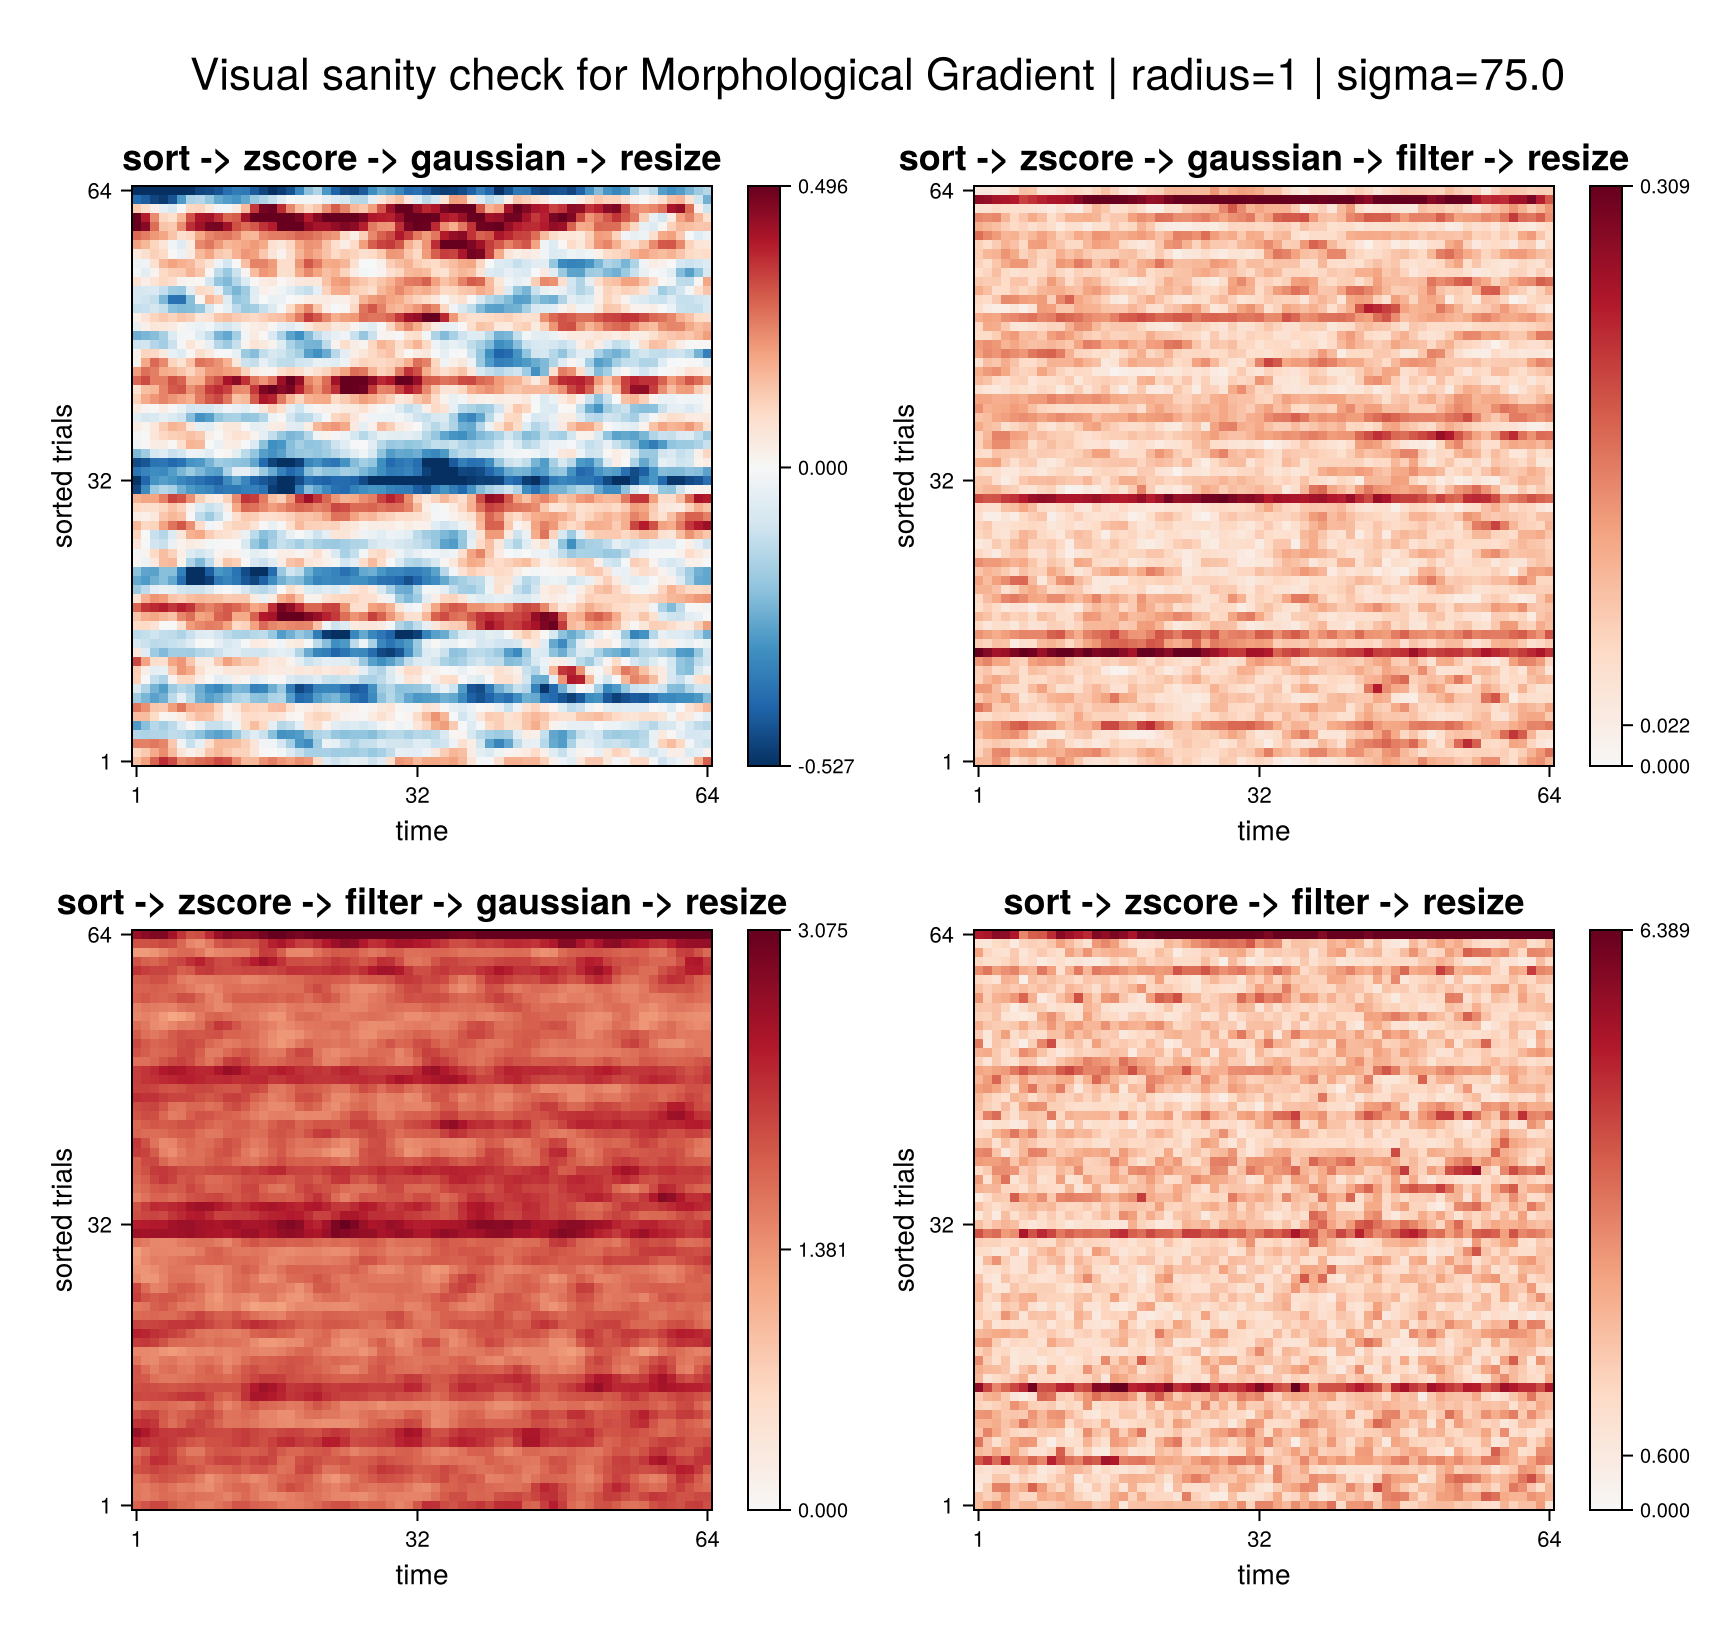

In [6]:
EXAMPLE_FILTER_NAME = "Morphological Gradient"
EXAMPLE_FILTER_SETTING = DEFAULT_FILTER_SETTING
EXAMPLE_GAUSSIAN_SETTING = DEFAULT_GAUSSIAN_SETTING

example_filter_specs = FILTER_SPECS_BY_RADIUS[EXAMPLE_FILTER_SETTING.radius]
example_filter_idx = findfirst(spec -> spec.name == EXAMPLE_FILTER_NAME, example_filter_specs)
@assert !isnothing(example_filter_idx) "Example filter not found in FILTER_SPECS_BY_RADIUS."
example_filter_spec = example_filter_specs[example_filter_idx]

example_row_idx = findfirst(==(1), sample_plan_df.binary_label)
@assert !isnothing(example_row_idx) "Could not find a positive sample for the visual check."
example_row = sample_plan_df[example_row_idx, :]

example_data_full, example_events_full = extract_channel_trials(
    erps,
    events,
    Int(example_row.channel);
    time_zero_idx = TIME_ZERO_IDX,
)

example_data_part = example_data_full[:, example_row.trial_indices]
example_events_part = example_events_full[example_row.trial_indices, :]

example_images = Dict{String, Matrix{Float32}}()
for pipeline_spec in PIPELINE_SPECS
    filter_fn = pipeline_spec.requires_filter ? example_filter_spec.fn : nothing
    low_pass_sigma = pipeline_uses_gaussian(pipeline_spec.name) ? Float32(EXAMPLE_GAUSSIAN_SETTING.sigma) : LOWPASS_SIGMA

    example_images[pipeline_spec.label] = preprocess_pipeline_from_trials(
        example_data_part,
        example_events_part,
        example_row.sort_var_symbol;
        pipeline_name = pipeline_spec.name,
        filter_fn = filter_fn,
        filter_repeats = FILTER_REPEATS,
        target_size = TARGET_SIZE,
        low_pass_sigma = low_pass_sigma,
        lowpass_kernel_size = LOWPASS_KERNEL_SIZE,
        filter_border = FILTER_BORDER,
    )
end

function preview_axis_ticks(n::Int)
    first_idx = 1
    mid_idx = Int(round((n + 1) / 2))
    last_idx = n
    vals = [first_idx, mid_idx, last_idx]
    labels = string.(vals)
    return vals, labels
end

function plot_pipeline_preview(example_pairs; title::String, q_low::Float64 = 0.01, q_high::Float64 = 0.99)
    n_images = length(example_pairs)
    n_cols = 2
    n_rows = cld(n_images, n_cols)

    panel_px = 290
    cb_px = 16
    row_px = 340

    fig = Figure(
        size = ((panel_px + cb_px + 46) * n_cols, row_px * n_rows),
        figure_padding = 24,
    )

    for (idx, (label, img)) in enumerate(example_pairs)
        row = cld(idx, n_cols)
        col = mod1(idx, n_cols)
        cell = GridLayout(fig[row, col])

        clipped, colorrange, tick_vals, tick_labels, cmap = clipped_color_stats_quantile_zero_ticks(
            Float32.(img);
            q_low = q_low,
            q_high = q_high,
        )

        n_trials, n_time = size(clipped)
        xtick_vals, xtick_labels = preview_axis_ticks(n_time)
        ytick_vals, ytick_labels = preview_axis_ticks(n_trials)

        ax = Axis(
            cell[1, 1];
            title = label,
            xlabel = "time",
            ylabel = "sorted trials",
            titlesize = 18,
            xlabelsize = 14,
            ylabelsize = 14,
            xticklabelsize = 11,
            yticklabelsize = 11,
            aspect = AxisAspect(1),
        )
        ax.xticks = (xtick_vals, xtick_labels)
        ax.yticks = (ytick_vals, ytick_labels)

        hm = heatmap!(
            ax,
            1:n_time,
            1:n_trials,
            permutedims(clipped, (2, 1));
            colormap = cmap,
            colorrange = colorrange,
        )

        Colorbar(
            cell[1, 2],
            hm;
            ticks = (tick_vals, tick_labels),
            ticklabelsize = 10,
            width = cb_px,
        )

        colsize!(cell, 1, Fixed(panel_px))
        colsize!(cell, 2, Fixed(cb_px))
        rowsize!(cell, 1, Fixed(panel_px))
    end

    rowgap!(fig.layout, 18)
    colgap!(fig.layout, 18)
    Label(fig[0, :], title, fontsize = 22)
    resize_to_layout!(fig)
    return fig
end

example_pairs = [(pipeline_spec.label, example_images[pipeline_spec.label]) for pipeline_spec in PIPELINE_SPECS]

fig_example = plot_pipeline_preview(
    example_pairs;
    title = "Visual sanity check for $(EXAMPLE_FILTER_NAME) | radius=$(EXAMPLE_FILTER_SETTING.radius) | sigma=$(EXAMPLE_GAUSSIAN_SETTING.sigma)",
    q_low = 0.01,
    q_high = 0.99,
)

fig_example


## Cross-Validation Experiment

This is the main experiment loop. It keeps the sample plan and fold split fixed, and evaluates the cross product of pipelines, active filters, filter settings, and Gaussian smoothing settings whenever the corresponding preprocessing step is active.


In [7]:
experiment_dfs = DataFrame[]
run_counter = 0
reference_filter_spec = (name = "Reference (no filter)", family = "reference", radius = nothing, fn = nothing)
not_applied_filter_setting = (label = "not_applied", radius = nothing, description = "filter not applied")
not_applied_gaussian_setting = (label = "not_applied", sigma = nothing, description = "gaussian not applied")

for pipeline_spec in PIPELINE_SPECS
    active_filter_settings = pipeline_spec.requires_filter ? FILTER_RADIUS_SETTING_SPECS : [not_applied_filter_setting]
    active_gaussian_settings = pipeline_uses_gaussian(pipeline_spec.name) ? GAUSSIAN_SIGMA_SETTING_SPECS : [not_applied_gaussian_setting]

    for gaussian_setting_spec in active_gaussian_settings
        effective_sigma = isnothing(gaussian_setting_spec.sigma) ? LOWPASS_SIGMA : Float32(gaussian_setting_spec.sigma)
        gaussian_setting_label = String(gaussian_setting_spec.label)
        gaussian_sigma_value = isnothing(gaussian_setting_spec.sigma) ? missing : Float32(gaussian_setting_spec.sigma)
        gaussian_setting = format_gaussian_setting(
            isnothing(gaussian_setting_spec.sigma) ? nothing : Float32(gaussian_setting_spec.sigma);
            lowpass_kernel_size = LOWPASS_KERNEL_SIZE,
            filter_border = FILTER_BORDER,
        )

        for filter_setting_spec in active_filter_settings
            filter_setting_label = String(filter_setting_spec.label)
            filter_radius_value = isnothing(filter_setting_spec.radius) ? missing : Int(filter_setting_spec.radius)
            active_filters = pipeline_spec.requires_filter ? FILTER_SPECS_BY_RADIUS[Int(filter_setting_spec.radius)] : [reference_filter_spec]

            for filter_spec in active_filters
                println()
                println(repeat("=", 100))
                println("Dataset configuration")
                println("  pipeline         : ", pipeline_spec.label)
                println("  filter           : ", filter_spec.name)
                println("  filter_setting   : ", filter_setting_label)
                println("  gaussian_setting : ", gaussian_setting_label)
                println(repeat("=", 100))

                filter_setting = format_filter_setting(
                    filter_spec.name,
                    filter_spec.family;
                    filter_radius = isnothing(filter_setting_spec.radius) ? nothing : Int(filter_setting_spec.radius),
                    filter_repeats = FILTER_REPEATS,
                )
                pipeline_name_str = String(pipeline_spec.name)
                pipeline_setting = format_pipeline_setting(
                    pipeline_name_str,
                    filter_spec.name;
                    filter_radius = isnothing(filter_setting_spec.radius) ? nothing : Int(filter_setting_spec.radius),
                    filter_repeats = FILTER_REPEATS,
                    low_pass_sigma = pipeline_uses_gaussian(pipeline_spec.name) ? Float32(effective_sigma) : nothing,
                    lowpass_kernel_size = LOWPASS_KERNEL_SIZE,
                    filter_border = FILTER_BORDER,
                    target_size = TARGET_SIZE,
                )

                dataset_df = materialize_single_channel_dataset(
                    erps,
                    events,
                    sample_plan_df;
                    time_zero_idx = TIME_ZERO_IDX,
                    pipeline_name = pipeline_spec.name,
                    filter_fn = filter_spec.fn,
                    filter_repeats = FILTER_REPEATS,
                    target_size = TARGET_SIZE,
                    low_pass_sigma = Float32(effective_sigma),
                    lowpass_kernel_size = LOWPASS_KERNEL_SIZE,
                    filter_border = FILTER_BORDER,
                )

                X = images_to_tensor(dataset_df.processed_img)
                y = Int.(dataset_df.binary_label)

                @assert y == y_binary "Labels must remain identical across preprocessing variants."
                @assert size(X, 4) == nrow(sample_plan_df) "Tensor sample count must match the shared sample plan."

                for model_spec in MODEL_SPECS
                    run_counter += 1
                    run_seed = TRAINING_SEED_BASE + 10_000 * run_counter

                    println(
                        "Running model: ", model_spec.name,
                        " | pipeline=", pipeline_name_str,
                        " | filter=", filter_spec.name,
                        " | filter_setting=", filter_setting_label,
                        " | gaussian_setting=", gaussian_setting_label,
                        " | seed=", run_seed,
                    )

                    df_model = run_model_cv(
                        model_spec.name,
                        model_spec.builder,
                        X,
                        y,
                        fold_val_indices;
                        nepochs = model_spec.nepochs,
                        lr = model_spec.lr,
                        batchsize = model_spec.batchsize,
                        is_pretrained = model_spec.is_pretrained,
                        seed = run_seed,
                        device = device,
                        before_fold! = before_fold!,
                        after_fold! = after_fold!,
                        show_epoch_logs = false,
                    )

                    insertcols!(
                        df_model,
                        1,
                        :pipeline_name => fill(pipeline_name_str, nrow(df_model)),
                        :pipeline_label => fill(pipeline_spec.label, nrow(df_model)),
                        :filter_name => fill(filter_spec.name, nrow(df_model)),
                        :filter_family => fill(filter_spec.family, nrow(df_model)),
                        :filter_setting_label => fill(filter_setting_label, nrow(df_model)),
                        :filter_radius => fill(filter_radius_value, nrow(df_model)),
                        :filter_repeats => fill(FILTER_REPEATS, nrow(df_model)),
                        :filter_setting => fill(filter_setting, nrow(df_model)),
                        :gaussian_setting_label => fill(gaussian_setting_label, nrow(df_model)),
                        :gaussian_sigma => fill(gaussian_sigma_value, nrow(df_model)),
                        :gaussian_setting => fill(gaussian_setting, nrow(df_model)),
                        :pipeline_setting => fill(pipeline_setting, nrow(df_model)),
                    )

                    push!(experiment_dfs, df_model)
                end
            end
        end
    end
end

experiment_cv_df = vcat(experiment_dfs...)
sort!(experiment_cv_df, [:model_name, :pipeline_name, :filter_name, :filter_setting_label, :gaussian_setting_label, :fold])

experiment_summary_df, experiment_single_value_df = summarize_cv_results(
    experiment_cv_df;
    group_cols = [
        :model_name,
        :pipeline_name,
        :pipeline_label,
        :filter_name,
        :filter_family,
        :filter_setting_label,
        :filter_radius,
        :filter_repeats,
        :filter_setting,
        :gaussian_setting_label,
        :gaussian_sigma,
        :gaussian_setting,
        :pipeline_setting,
    ],
)

println("\nFinished experiment grid.")
println("Rows in fold-level result table: ", nrow(experiment_cv_df))
println("Rows in summary table          : ", nrow(experiment_summary_df))



Dataset configuration
  pipeline         : sort -> zscore -> gaussian -> resize
  filter           : Reference (no filter)
  filter_setting   : not_applied
  gaussian_setting : low_25
Running model: resnet18_random | pipeline=gaussian_reference | filter=Reference (no filter) | filter_setting=not_applied | gaussian_setting=low_25 | seed=14772943310575
Running model: resnet18_pretrained | pipeline=gaussian_reference | filter=Reference (no filter) | filter_setting=not_applied | gaussian_setting=low_25 | seed=14772943320575

Dataset configuration
  pipeline         : sort -> zscore -> gaussian -> resize
  filter           : Reference (no filter)
  filter_setting   : not_applied
  gaussian_setting : mid_50
Running model: resnet18_random | pipeline=gaussian_reference | filter=Reference (no filter) | filter_setting=not_applied | gaussian_setting=mid_50 | seed=14772943330575
Running model: resnet18_pretrained | pipeline=gaussian_reference | filter=Reference (no filter) | filter_setting=not_ap

## Result Comparison

The tables below answer four questions:

1. Which preprocessing setup is best overall for each model?
2. Which filter and filter setting is best for each pipeline family?
3. Which Gaussian setting is best for each pipeline family that uses Gaussian smoothing?
4. Does any filter-based pipeline beat the best Gaussian reference setting?


In [8]:
println("\nFold-level results:")
pretty_table(
    experiment_cv_df[:, [
        :model_name,
        :pipeline_name,
        :filter_name,
        :filter_setting_label,
        :gaussian_setting_label,
        :fold,
        :balanced_accuracy,
        :macro_f1,
        :train_time_s,
        :pretrained_params_loaded,
    ]];
    table_kwargs...,
)

println("\nSummary (mean ± std across folds):")
pretty_table(
    experiment_summary_df[:, [
        :model_name,
        :pipeline_name,
        :filter_name,
        :filter_setting_label,
        :filter_radius,
        :gaussian_setting_label,
        :gaussian_sigma,
        :balanced_accuracy_mean,
        :balanced_accuracy_std,
        :macro_f1_mean,
        :macro_f1_std,
        :train_time_mean_s,
        :pretrained_params_loaded,
    ]];
    table_kwargs...,
)

overall_rank_df = sort(
    copy(experiment_single_value_df[:, [
        :model_name,
        :pipeline_name,
        :pipeline_label,
        :filter_name,
        :filter_setting_label,
        :filter_radius,
        :filter_setting,
        :gaussian_setting_label,
        :gaussian_sigma,
        :gaussian_setting,
        :pipeline_setting,
        :balanced_accuracy,
        :macro_f1,
        :train_time_s,
        :pretrained_params_loaded,
    ]]),
    [:balanced_accuracy, :macro_f1];
    rev = [true, true],
)

top_n = min(12, nrow(overall_rank_df))
println("\nTop configurations overall:")
pretty_table(overall_rank_df[1:top_n, :]; table_kwargs...)

model_levels = [spec.name for spec in MODEL_SPECS]
pipeline_levels = String.(getfield.(PIPELINE_SPECS, :name))

best_pipeline_rows = NamedTuple[]
for model_name in model_levels
    for pipeline_name in pipeline_levels
        sdf = copy(experiment_single_value_df[
            (String.(experiment_single_value_df.model_name) .== model_name) .&
            (String.(experiment_single_value_df.pipeline_name) .== pipeline_name),
            :,
        ])
        isempty(sdf) && continue

        sort!(sdf, [:balanced_accuracy, :macro_f1]; rev = [true, true])
        r = sdf[1, :]
        push!(best_pipeline_rows, (
            model_name = model_name,
            pipeline_name = String(r.pipeline_name),
            pipeline_label = String(r.pipeline_label),
            filter_name = String(r.filter_name),
            filter_setting_label = String(r.filter_setting_label),
            filter_radius = ismissing(r.filter_radius) ? missing : Int(r.filter_radius),
            filter_setting = String(r.filter_setting),
            gaussian_setting_label = String(r.gaussian_setting_label),
            gaussian_sigma = ismissing(r.gaussian_sigma) ? missing : Float32(r.gaussian_sigma),
            gaussian_setting = String(r.gaussian_setting),
            pipeline_setting = String(r.pipeline_setting),
            balanced_accuracy = Float64(r.balanced_accuracy),
            macro_f1 = Float64(r.macro_f1),
            train_time_s = Float64(r.train_time_s),
            pretrained_params_loaded = Int(r.pretrained_params_loaded),
        ))
    end
end
best_pipeline_df = DataFrame(best_pipeline_rows)
sort!(best_pipeline_df, [:model_name, :pipeline_name])

println("\nBest filter and settings per model and pipeline:")
pretty_table(best_pipeline_df; table_kwargs...)

challenge_rows = NamedTuple[]
for model_name in model_levels
    reference_rows = copy(experiment_single_value_df[
        (String.(experiment_single_value_df.model_name) .== model_name) .&
        (String.(experiment_single_value_df.pipeline_name) .== "gaussian_reference"),
        :,
    ])
    @assert !isempty(reference_rows) "Missing gaussian reference rows for $(model_name)."
    sort!(reference_rows, [:balanced_accuracy, :macro_f1]; rev = [true, true])
    ref_row = reference_rows[1, :]

    challengers = copy(experiment_single_value_df[
        (String.(experiment_single_value_df.model_name) .== model_name) .&
        (String.(experiment_single_value_df.pipeline_name) .!= "gaussian_reference"),
        :,
    ])
    sort!(challengers, [:balanced_accuracy, :macro_f1]; rev = [true, true])
    best_row = challengers[1, :]

    has_gain = Float64(best_row.balanced_accuracy) > Float64(ref_row.balanced_accuracy)

    push!(challenge_rows, (
        model_name = model_name,
        reference_filter = String(ref_row.filter_name),
        reference_gaussian_setting_label = String(ref_row.gaussian_setting_label),
        reference_gaussian_sigma = ismissing(ref_row.gaussian_sigma) ? missing : Float32(ref_row.gaussian_sigma),
        reference_gaussian_setting = String(ref_row.gaussian_setting),
        reference_balanced_accuracy = Float64(ref_row.balanced_accuracy),
        reference_macro_f1 = Float64(ref_row.macro_f1),
        best_challenger_pipeline = String(best_row.pipeline_name),
        best_challenger_pipeline_label = String(best_row.pipeline_label),
        best_challenger_filter = String(best_row.filter_name),
        best_challenger_filter_setting_label = String(best_row.filter_setting_label),
        best_challenger_filter_radius = ismissing(best_row.filter_radius) ? missing : Int(best_row.filter_radius),
        best_challenger_filter_setting = String(best_row.filter_setting),
        best_challenger_gaussian_setting_label = String(best_row.gaussian_setting_label),
        best_challenger_gaussian_sigma = ismissing(best_row.gaussian_sigma) ? missing : Float32(best_row.gaussian_sigma),
        best_challenger_gaussian_setting = String(best_row.gaussian_setting),
        best_challenger_pipeline_setting = String(best_row.pipeline_setting),
        best_challenger_balanced_accuracy = Float64(best_row.balanced_accuracy),
        best_challenger_macro_f1 = Float64(best_row.macro_f1),
        delta_balanced_accuracy = Float64(best_row.balanced_accuracy) - Float64(ref_row.balanced_accuracy),
        delta_macro_f1 = Float64(best_row.macro_f1) - Float64(ref_row.macro_f1),
        gain_driver_filter = has_gain ? String(best_row.filter_name) : "No filter-based gain over reference",
        gain_driver_filter_setting = has_gain ? String(best_row.filter_setting) : "Gaussian reference remains best",
        gain_driver_gaussian_setting = has_gain ? String(best_row.gaussian_setting) : String(ref_row.gaussian_setting),
    ))
end
challenge_df = DataFrame(challenge_rows)
sort!(challenge_df, :model_name)

println("\nBest challenger against the best Gaussian reference setting:")
pretty_table(
    challenge_df[:, [
        :model_name,
        :reference_gaussian_setting_label,
        :reference_gaussian_sigma,
        :reference_balanced_accuracy,
        :best_challenger_pipeline_label,
        :best_challenger_filter,
        :best_challenger_filter_setting_label,
        :best_challenger_gaussian_setting_label,
        :best_challenger_balanced_accuracy,
        :delta_balanced_accuracy,
        :gain_driver_filter,
    ]];
    table_kwargs...,
)



Fold-level results:
┌─────────────────────┬──────────────────────┬────────────────────────┬──────────────────────┬────────────────────────┬───────┬───────────────────┬──────────┬──────────────┬──────────────────────────┐
│          model_name │        pipeline_name │            filter_name │ filter_setting_label │ gaussian_setting_label │  fold │ balanced_accuracy │ macro_f1 │ train_time_s │ pretrained_params_loaded │
│              String │               String │                 String │               String │                 String │ Int64 │           Float64 │  Float64 │      Float64 │                    Int64 │
├─────────────────────┼──────────────────────┼────────────────────────┼──────────────────────┼────────────────────────┼───────┼───────────────────┼──────────┼──────────────┼──────────────────────────┤
│ resnet18_pretrained │          filter_only │                 Bothat │              default │            not_applied │     1 │          0.709394 │ 0.721953 │      1.05185 │  

Excessive output truncated after 563622 bytes.

## Balanced Accuracy Ranking and Gain Attribution

These tables sort the configurations by balanced accuracy and make both the responsible filter setting and the Gaussian smoothing setting explicit.


In [9]:
balanced_accuracy_rank_df = sort(
    copy(experiment_single_value_df[:, [
        :model_name,
        :pipeline_label,
        :filter_name,
        :filter_setting_label,
        :filter_radius,
        :filter_setting,
        :gaussian_setting_label,
        :gaussian_sigma,
        :gaussian_setting,
        :pipeline_setting,
        :balanced_accuracy,
        :macro_f1,
        :train_time_s,
        :pretrained_params_loaded,
    ]]),
    [:balanced_accuracy, :macro_f1];
    rev = [true, true],
)

println("\nBalanced-accuracy ranking with responsible filter and Gaussian settings:")
pretty_table(balanced_accuracy_rank_df; table_kwargs...)

gain_rank_df = sort(
    copy(challenge_df[:, [
        :model_name,
        :reference_gaussian_setting_label,
        :reference_gaussian_sigma,
        :reference_balanced_accuracy,
        :best_challenger_pipeline_label,
        :best_challenger_filter,
        :best_challenger_filter_setting_label,
        :best_challenger_filter_radius,
        :best_challenger_filter_setting,
        :best_challenger_gaussian_setting_label,
        :best_challenger_gaussian_sigma,
        :best_challenger_gaussian_setting,
        :best_challenger_balanced_accuracy,
        :delta_balanced_accuracy,
        :gain_driver_filter,
        :gain_driver_filter_setting,
        :gain_driver_gaussian_setting,
    ]]),
    :delta_balanced_accuracy;
    rev = true,
)

println("\nGain attribution against the best Gaussian reference (sorted by balanced accuracy gain):")
pretty_table(gain_rank_df; table_kwargs...)


## Tabular Overview

This overview condenses the main result table into one row per preprocessing configuration and one metric column per model. It is meant as a compact table for quick comparison.


In [10]:
overview_base_df = sort(
    copy(experiment_single_value_df[:, [
        :pipeline_label,
        :filter_name,
        :filter_setting_label,
        :filter_radius,
        :gaussian_setting_label,
        :gaussian_sigma,
        :balanced_accuracy,
        :macro_f1,
        :model_name,
    ]]),
    [:pipeline_label, :filter_name, :filter_setting_label, :gaussian_setting_label, :model_name],
)

overview_balacc_df = unstack(
    overview_base_df[:, [
        :pipeline_label,
        :filter_name,
        :filter_setting_label,
        :filter_radius,
        :gaussian_setting_label,
        :gaussian_sigma,
        :model_name,
        :balanced_accuracy,
    ]],
    [:pipeline_label, :filter_name, :filter_setting_label, :filter_radius, :gaussian_setting_label, :gaussian_sigma],
    :model_name,
    :balanced_accuracy,
)

overview_macro_f1_df = unstack(
    overview_base_df[:, [
        :pipeline_label,
        :filter_name,
        :filter_setting_label,
        :filter_radius,
        :gaussian_setting_label,
        :gaussian_sigma,
        :model_name,
        :macro_f1,
    ]],
    [:pipeline_label, :filter_name, :filter_setting_label, :filter_radius, :gaussian_setting_label, :gaussian_sigma],
    :model_name,
    :macro_f1,
)

model_cols = [spec.name for spec in MODEL_SPECS if spec.name in names(overview_balacc_df)]
if !isempty(model_cols)
    overview_balacc_df.best_balanced_accuracy = [begin
        vals = collect(skipmissing([Float64(row[col]) for col in model_cols]))
        isempty(vals) ? missing : maximum(vals)
    end for row in eachrow(overview_balacc_df)]
    overview_macro_f1_df.best_macro_f1 = [begin
        vals = collect(skipmissing([Float64(row[col]) for col in model_cols]))
        isempty(vals) ? missing : maximum(vals)
    end for row in eachrow(overview_macro_f1_df)]
    sort!(overview_balacc_df, :best_balanced_accuracy, rev = true)
    sort!(overview_macro_f1_df, :best_macro_f1, rev = true)
end

println("
Compact overview table: balanced accuracy by model")
pretty_table(overview_balacc_df; table_kwargs...)

println("
Compact overview table: macro-F1 by model")
pretty_table(overview_macro_f1_df; table_kwargs...)



## Plots

The plots summarize the best filter per pipeline for each model.


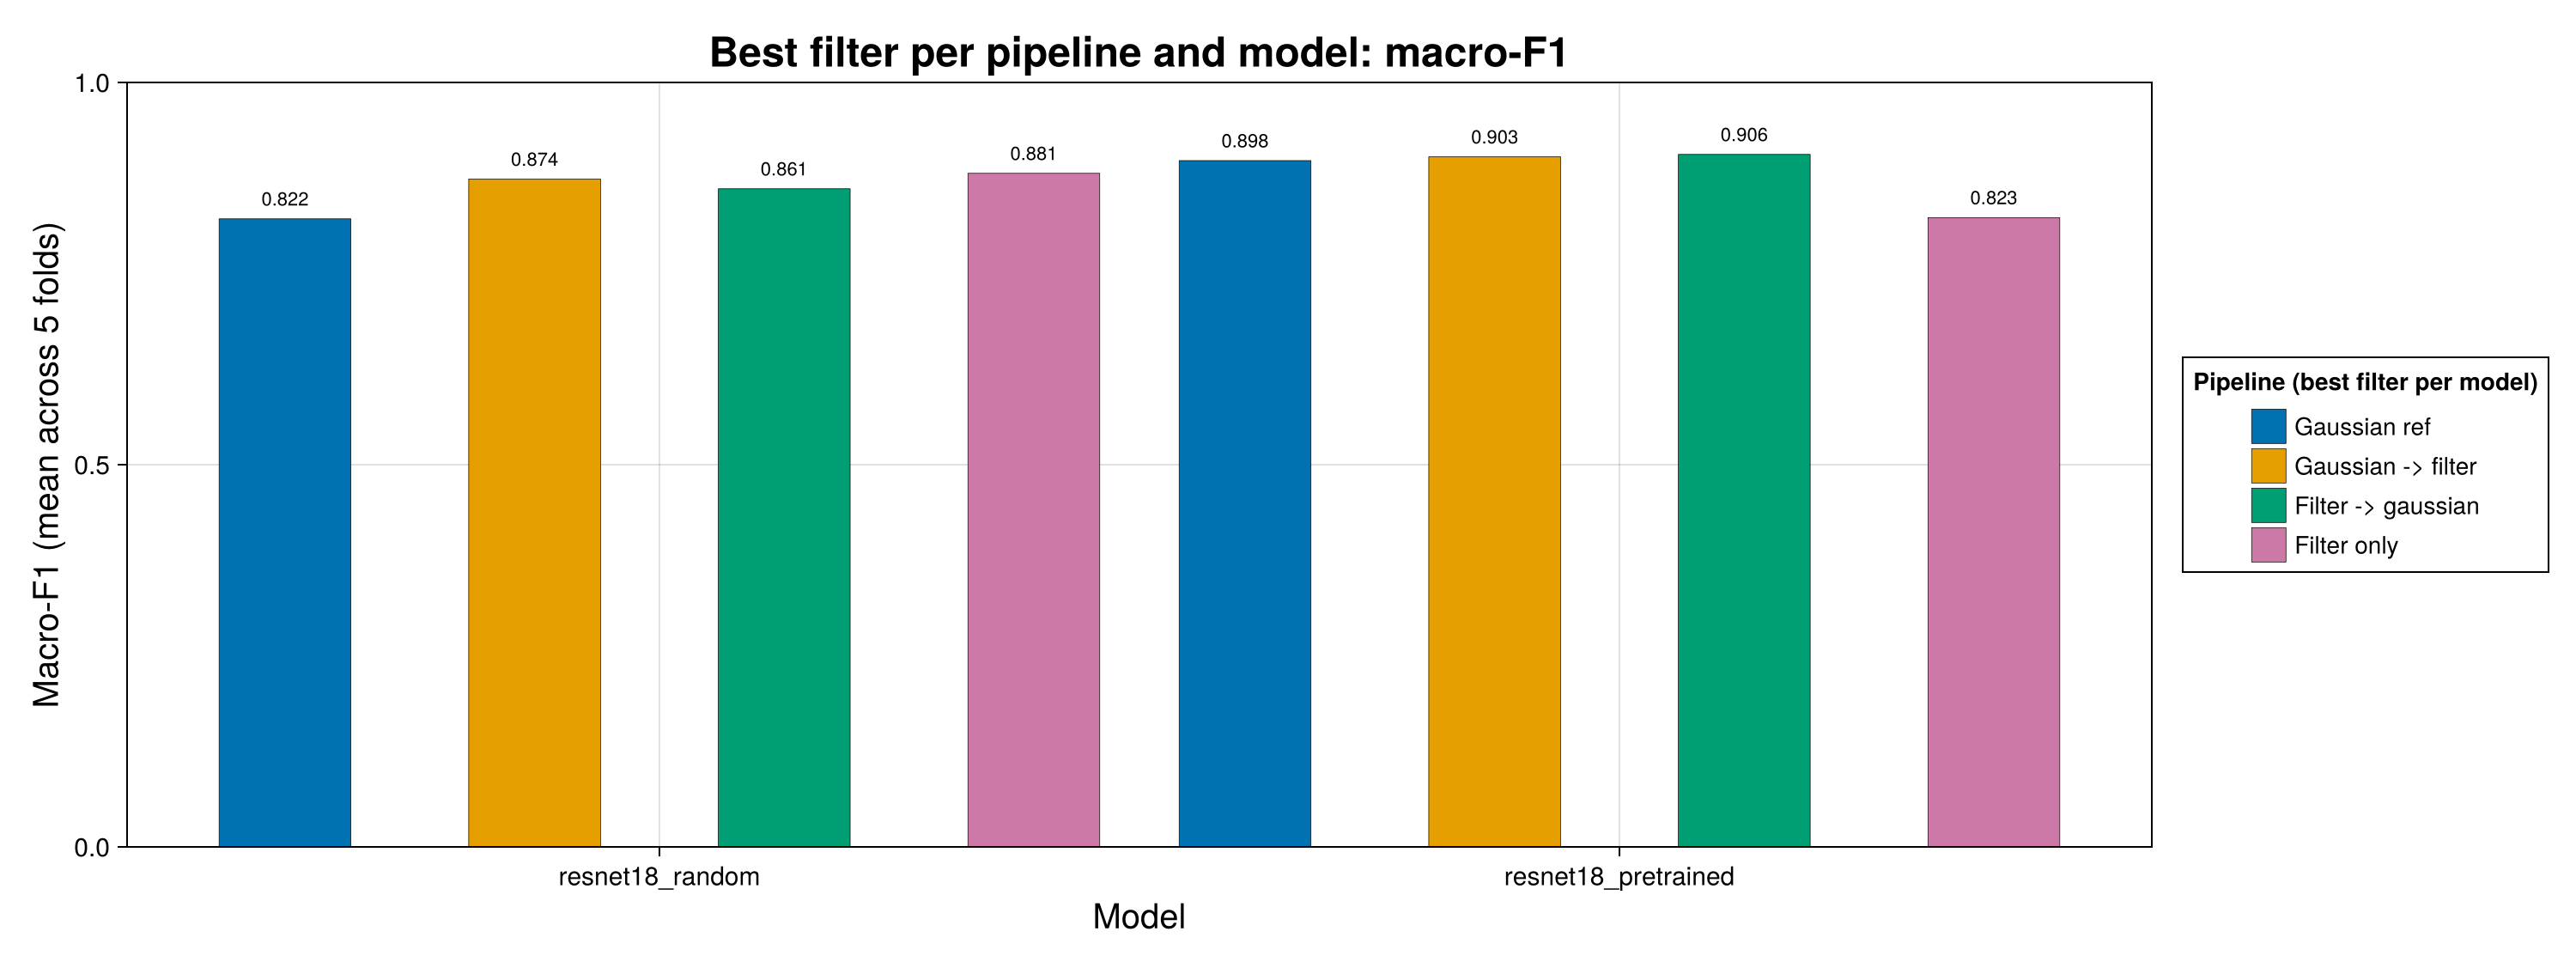

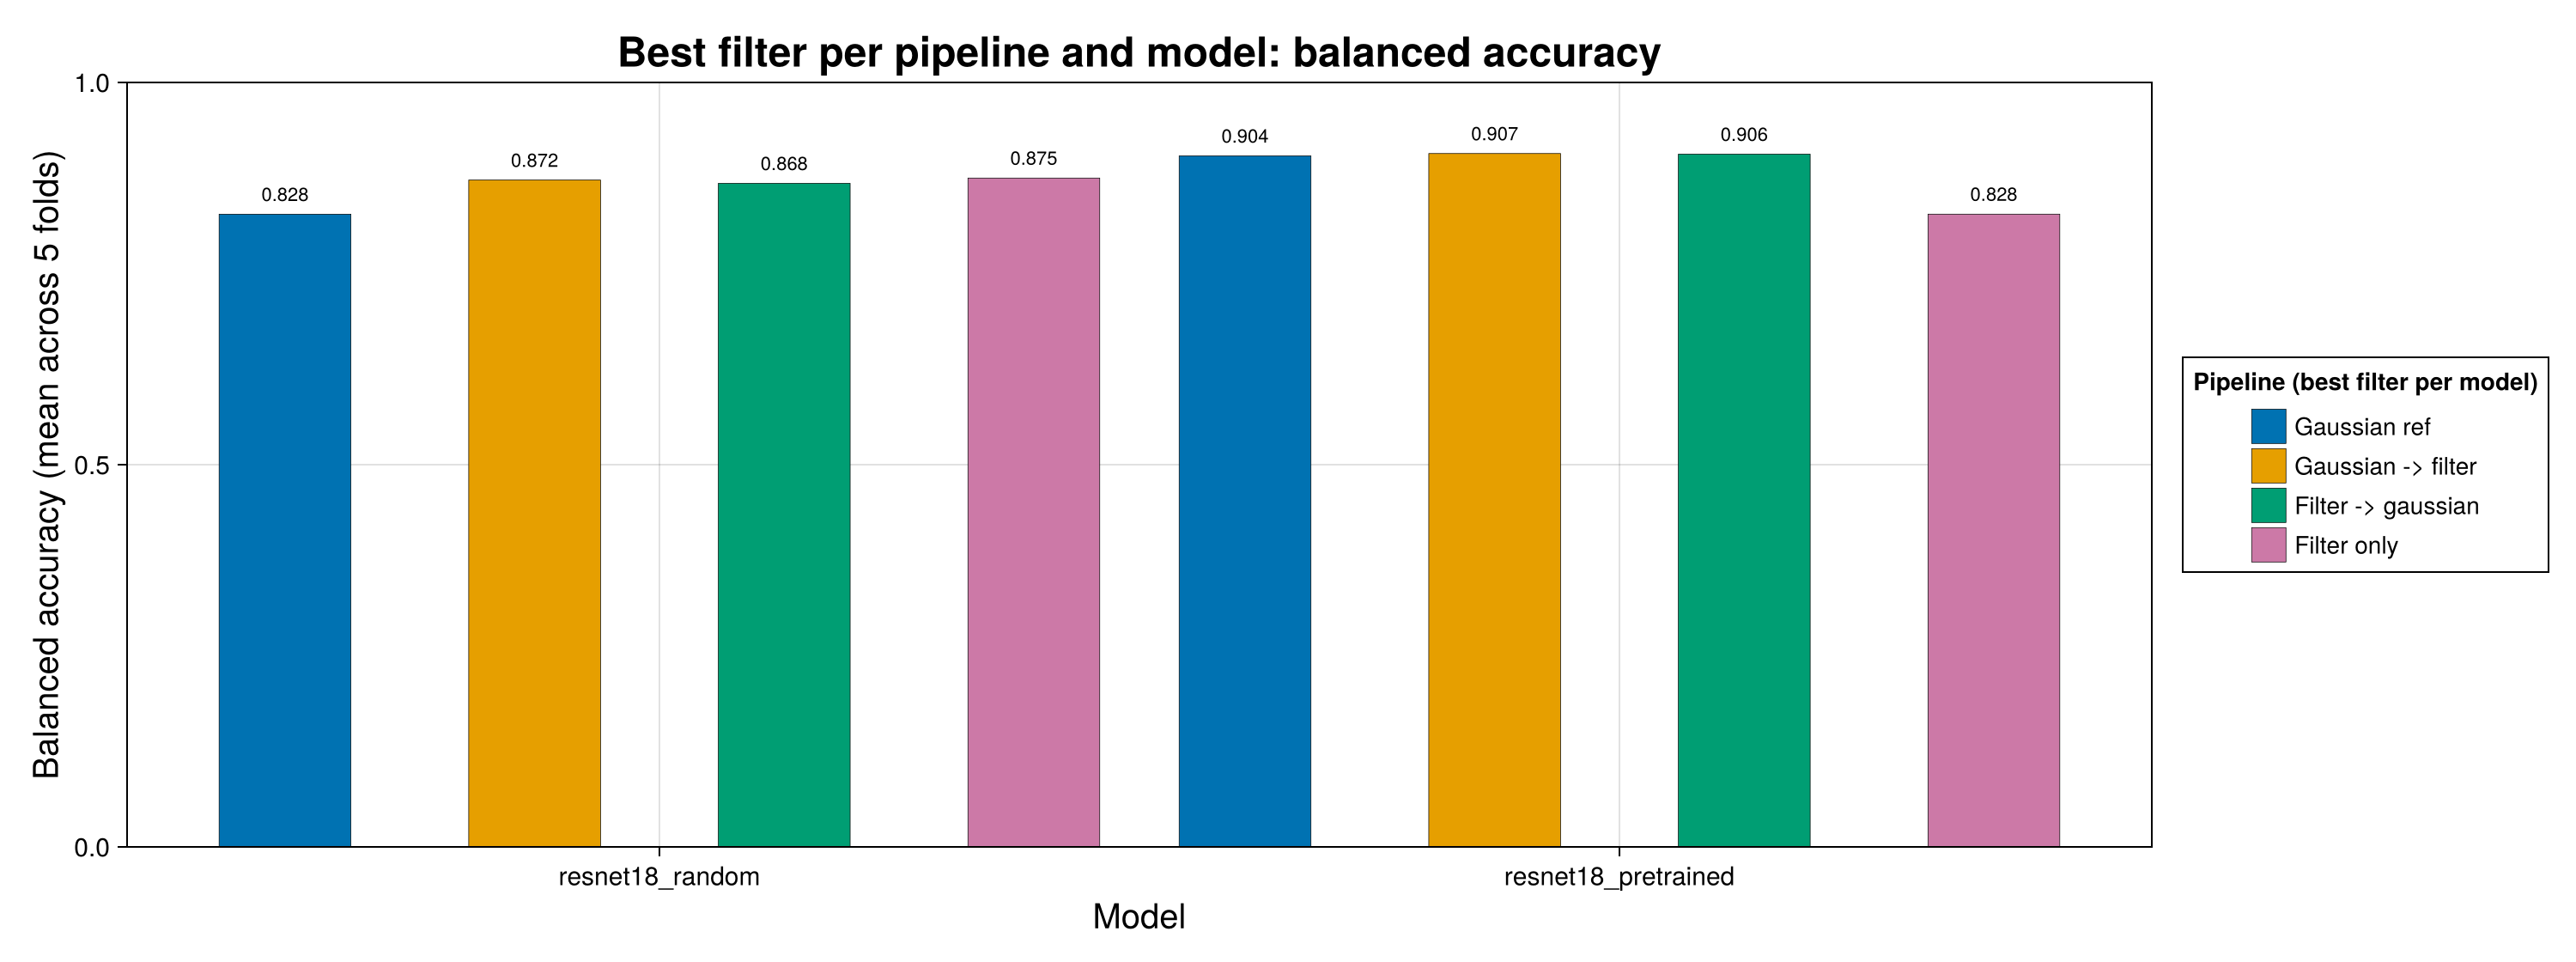

In [11]:

pipeline_order = String.(getfield.(PIPELINE_SPECS, :name))
pipeline_short_label_map = Dict(
    "gaussian_reference" => "Gaussian ref",
    "gaussian_then_filter" => "Gaussian -> filter",
    "filter_then_gaussian" => "Filter -> gaussian",
    "filter_only" => "Filter only",
)
model_order = [spec.name for spec in MODEL_SPECS]

function best_pipeline_metric(model_name::String, pipeline_name::String, metric_col::Symbol)
    idx = findfirst(
        (String.(best_pipeline_df.model_name) .== model_name) .&
        (String.(best_pipeline_df.pipeline_name) .== pipeline_name),
    )
    @assert !isnothing(idx) "Missing row for model=$(model_name), pipeline=$(pipeline_name)."
    return Float64(best_pipeline_df[idx, metric_col])
end

function plot_best_pipeline_metric(metric_col::Symbol, ylabel_text::String, title_text::String)
    fig = Figure(size = (1500, 560))
    ax = Axis(
        fig[1, 1],
        title = title_text,
        xlabel = "Model",
        ylabel = ylabel_text,
        xticks = (collect(1:length(model_order)), model_order),
        titlesize = 24,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 15,
        yticklabelsize = 15,
    )

    n_pipelines = length(pipeline_order)
    offset_span = 0.78
    offsets = collect(range(-offset_span / 2, offset_span / 2, length = n_pipelines))
    bar_width = (offset_span / n_pipelines) * 0.88
    colors = Makie.wong_colors()
    x = collect(1:length(model_order))

    for (j, pipeline_name) in enumerate(pipeline_order)
        y = [best_pipeline_metric(model_name, pipeline_name, metric_col) for model_name in model_order]
        xj = x .+ offsets[j]

        barplot!(
            ax,
            xj,
            y;
            width = bar_width,
            color = colors[((j - 1) % length(colors)) + 1],
            strokecolor = :black,
            strokewidth = 0.35,
            label = pipeline_short_label_map[pipeline_name],
        )

        text!(
            ax,
            xj,
            y .+ 0.012,
            text = string.(round.(y, digits = 3)),
            align = (:center, :bottom),
            fontsize = 11,
            color = :black,
        )
    end

    ylims!(ax, 0, 1)
    Legend(fig[1, 2], ax, "Pipeline (best filter per model)")
    return fig
end

fig_best_balacc = plot_best_pipeline_metric(
    :balanced_accuracy,
    "Balanced accuracy (mean across 5 folds)",
    "Best filter per pipeline and model: balanced accuracy",
)

fig_best_macro_f1 = plot_best_pipeline_metric(
    :macro_f1,
    "Macro-F1 (mean across 5 folds)",
    "Best filter per pipeline and model: macro-F1",
)

display(fig_best_macro_f1)
fig_best_balacc
